# 📊 EdgeGuard-IoT: Step 1 - Professional EDA & Data Preprocessing Pipeline
**Dataset:** CIC-IoT-2023  
**Objective:** Comprehensive Exploratory Data Analysis (EDA) comparing raw dataset vs balanced preprocessed dataset, mapping 34 attack subcategories into 8 high-level classes, feature normalization, and stratified dataset partitioning.

In [1]:
import os
import glob
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)
print('[+] Libraries and Seaborn theme loaded successfully.')

[+] Libraries and Seaborn theme loaded successfully.


--- 
## 1. Raw Dataset Exploration (ANTES del Preprocesamiento)
Analizamos la distribución original del dataset masivo **CIC-IoT-2023** leyendo fragmentos (chunks) de los archivos CSV.

Total de archivos CSV masivos encontrados: 63


Total de muestras analizadas en la muestra RAW: 2,158,185
Total de subcategorías únicas de ataques: 34


C:\Users\IGNACIO\AppData\Local\Temp\ipykernel_32508\4156031830.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=raw_counts.values, y=raw_counts.index, palette='magma')


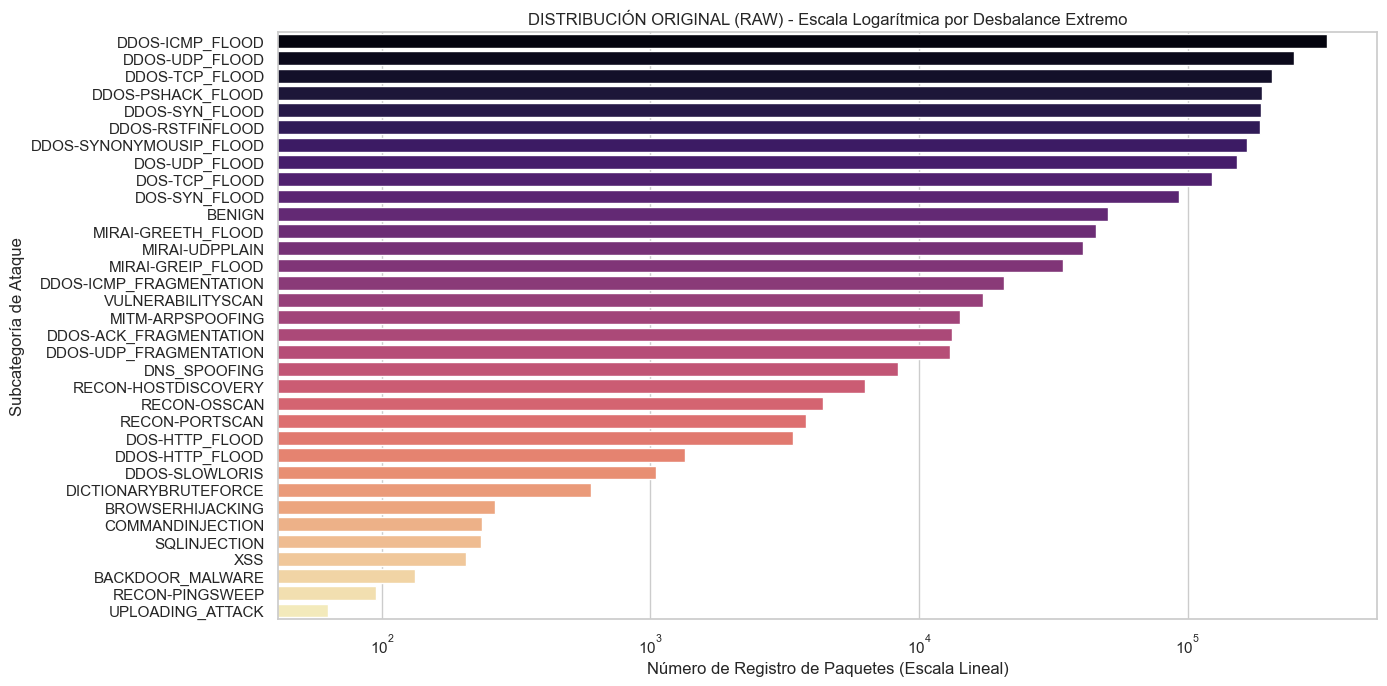

In [2]:
DATA_DIR = r'E:\PROYECTO DE INVESTIGACION\dataset\MERGED_CSV\MERGED_CSV'
csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
print(f'Total de archivos CSV masivos encontrados: {len(csv_files)}')

# Sample raw label distribution across first 3 CSV files
raw_labels = []
for f in csv_files[:3]:
    df_chunk = pd.read_csv(f, usecols=['Label'])
    raw_labels.append(df_chunk['Label'])

df_raw_sample = pd.concat(raw_labels, ignore_index=True)
raw_counts = df_raw_sample.value_counts()

print(f'Total de muestras analizadas en la muestra RAW: {len(df_raw_sample):,}')
print(f'Total de subcategorías únicas de ataques: {len(raw_counts)}')

# Bar chart of Raw Subcategories (Before preprocessing)
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=raw_counts.values, y=raw_counts.index, palette='magma')
plt.title('DISTRIBUCIÓN ORIGINAL (RAW) - 34 Subcategorías de Ataques CIC-IoT-2023', fontsize=14, fontweight='bold')
plt.xlabel('Número de Registro de Paquetes (Escala Lineal)', fontsize=12)
plt.ylabel('Subcategoría de Ataque', fontsize=12)
plt.xscale('log')
plt.title('DISTRIBUCIÓN ORIGINAL (RAW) - Escala Logarítmica por Desbalance Extremo')
plt.tight_layout()
plt.show()

--- 
## 2. Mapeo de Subcategorías a 8 Clases Principales
Agrupamos las 34 subcategorías heterogéneas en **8 clases principales** (`DDoS`, `DoS`, `Mirai`, `Recon`, `Spoofing`, `Brute Force`, `Web-based` y `Benign`).

In [3]:
LABEL_MAP = {
    'DDOS-ICMP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS', 'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS', 'DDOS-SYN_FLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS', 'DDOS-ICMP_FRAGMENTATION': 'DDoS',
    'DDOS-ACK_FRAGMENTATION': 'DDoS', 'DDOS-UDP_FRAGMENTATION': 'DDoS',
    'DDOS-HTTP_FLOOD': 'DDoS', 'DDOS-SLOWLORIS': 'DDoS',
    'DOS-UDP_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS', 'DOS-SYN_FLOOD': 'DoS', 'DOS-HTTP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai', 'MIRAI-GREIP_FLOOD': 'Mirai',
    'VULNERABILITYSCAN': 'Recon', 'RECON-HOSTDISCOVERY': 'Recon', 'RECON-OSSCAN': 'Recon',
    'RECON-PORTSCAN': 'Recon', 'RECON-PINGSWEEP': 'Recon',
    'MITM-ARPSPOOFING': 'Spoofing', 'DNS_SPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'Brute Force',
    'BROWSERHIJACKING': 'Web-based', 'SQLINJECTION': 'Web-based', 'COMMANDINJECTION': 'Web-based',
    'XSS': 'Web-based', 'BACKDOOR_MALWARE': 'Web-based', 'UPLOADING_ATTACK': 'Web-based',
    'BENIGN': 'Benign'
}

df_raw_sample['Category'] = df_raw_sample.map(LABEL_MAP)
cat_raw_counts = df_raw_sample['Category'].value_counts()

print('Distribución agrupada ANTES del Balanceo:')
for cat, cnt in cat_raw_counts.items():
    print(f' - {cat:12s}: {cnt:,} muestras ({cnt/len(df_raw_sample)*100:.2f}%)')

Distribución agrupada ANTES del Balanceo:
 - DDoS        : 1,559,553 muestras (72.26%)
 - DoS         : 371,196 muestras (17.20%)
 - Mirai       : 120,720 muestras (5.59%)
 - Benign      : 50,678 muestras (2.35%)
 - Recon       : 31,814 muestras (1.47%)
 - Spoofing    : 22,485 muestras (1.04%)
 - Web-based   : 1,136 muestras (0.05%)
 - Brute Force : 603 muestras (0.03%)


--- 
## 3. Dataset Procesado y Balanceado (DESPUÉS del Preprocesamiento)
Cargamos los datasets `.parquet` procesados y balanceados para comparar visualmente el ANTES vs DESPUÉS.

C:\Users\IGNACIO\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\IGNACIO\AppData\Local\Temp\ipykernel_32508\1102288182.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_raw_counts.values, y=cat_raw_counts.index, ax=axes[0], palette='Reds_r')
C:\Users\IGNACIO\AppData\Local\Temp\ipykernel_32508\1102288182.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=Fals

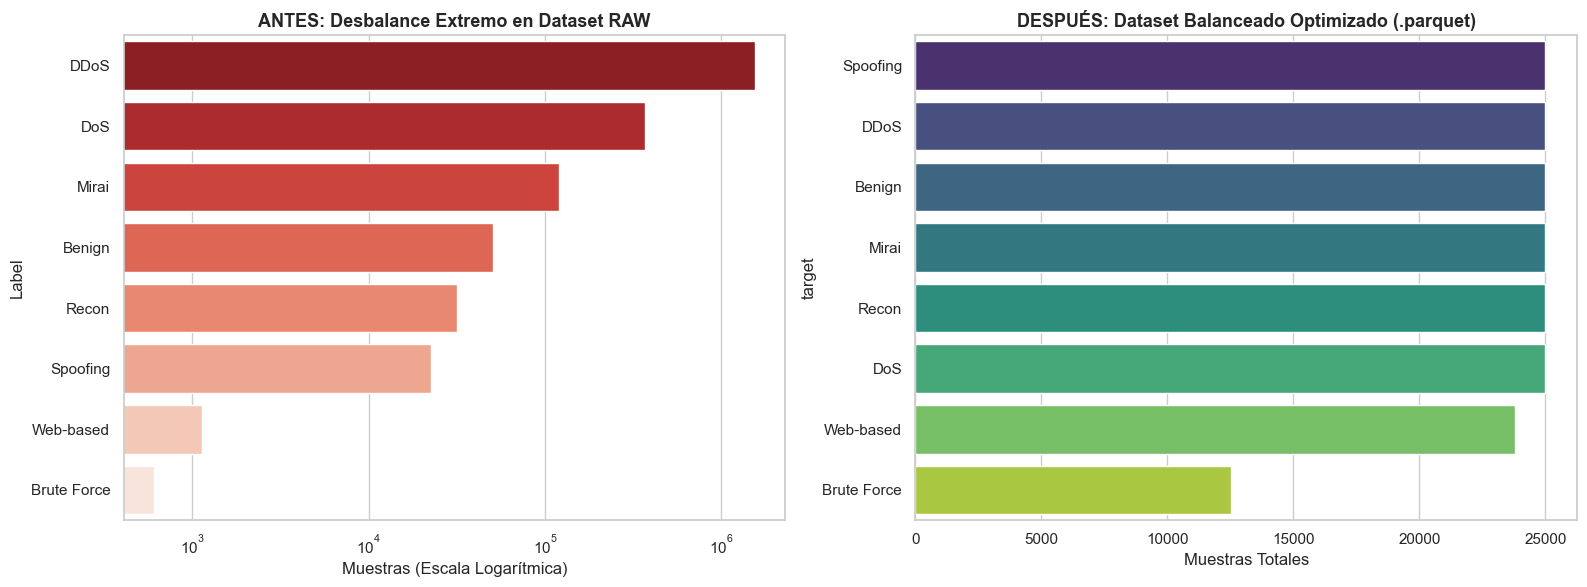

In [4]:
train_df = pd.read_parquet('../data/processed/train.parquet')
val_df = pd.read_parquet('../data/processed/val.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')
label_encoder = joblib.load('../models/label_encoder.joblib')
with open('../models/meta_info.json') as f:
    meta_info = json.load(f)

feature_cols = meta_info['feature_names']
classes = meta_info['classes']

# Combine for total counts
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
balanced_counts = all_df['target'].map(dict(enumerate(classes))).value_counts()

# Comparison Plot: Before vs After Balancing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=cat_raw_counts.values, y=cat_raw_counts.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('ANTES: Desbalance Extremo en Dataset RAW', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Muestras (Escala Logarítmica)')
axes[0].set_xscale('log')

sns.barplot(x=balanced_counts.values, y=balanced_counts.index, ax=axes[1], palette='viridis')
axes[1].set_title('DESPUÉS: Dataset Balanceado Optimizado (.parquet)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Muestras Totales')

plt.tight_layout()
plt.show()

--- 
## 4. Análisis de Características Numéricas y Normalización (MinMaxScaler)
Visualizamos el impacto del escalamiento `MinMaxScaler` en las 39 características de flujo de red.

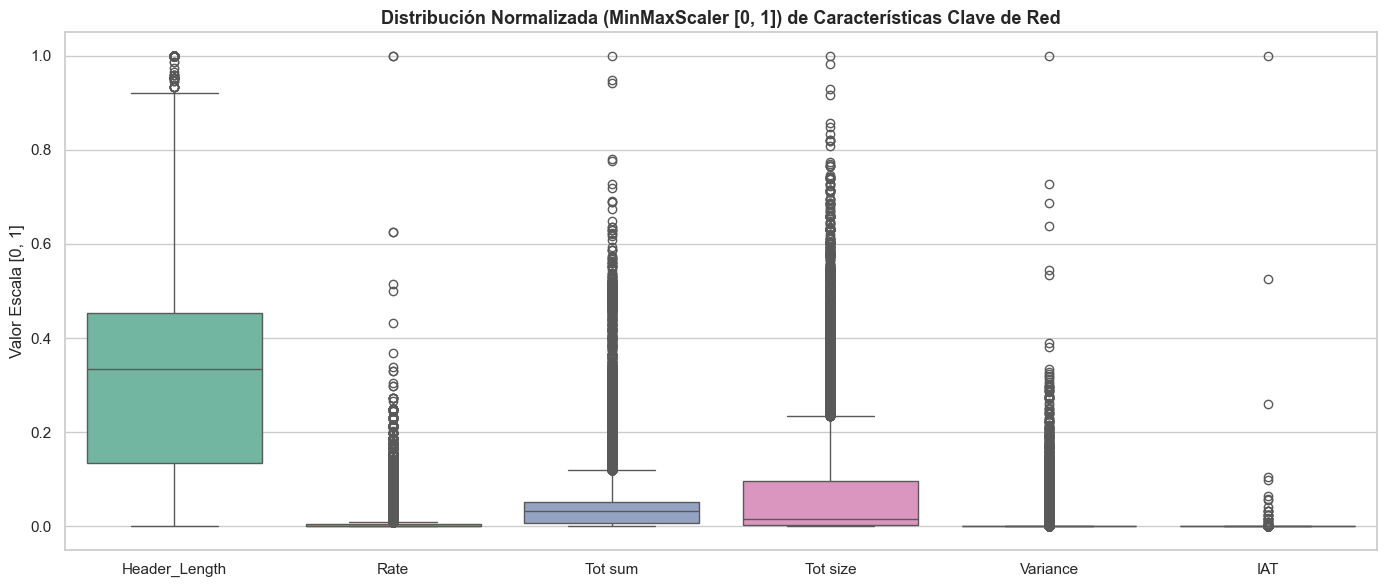

In [5]:
sample_features = ['Header_Length', 'Rate', 'Tot sum', 'Tot size', 'Variance', 'IAT']

plt.figure(figsize=(14, 6))
sns.boxplot(data=train_df[sample_features], palette='Set2')
plt.title('Distribución Normalizada (MinMaxScaler [0, 1]) de Características Clave de Red', fontsize=13, fontweight='bold')
plt.ylabel('Valor Escala [0, 1]')
plt.tight_layout()
plt.show()

--- 
## 5. Matriz de Correlación de Características de Red
Analizamos la correlación lineal entre las características numéricas principales del tráfico IoT.

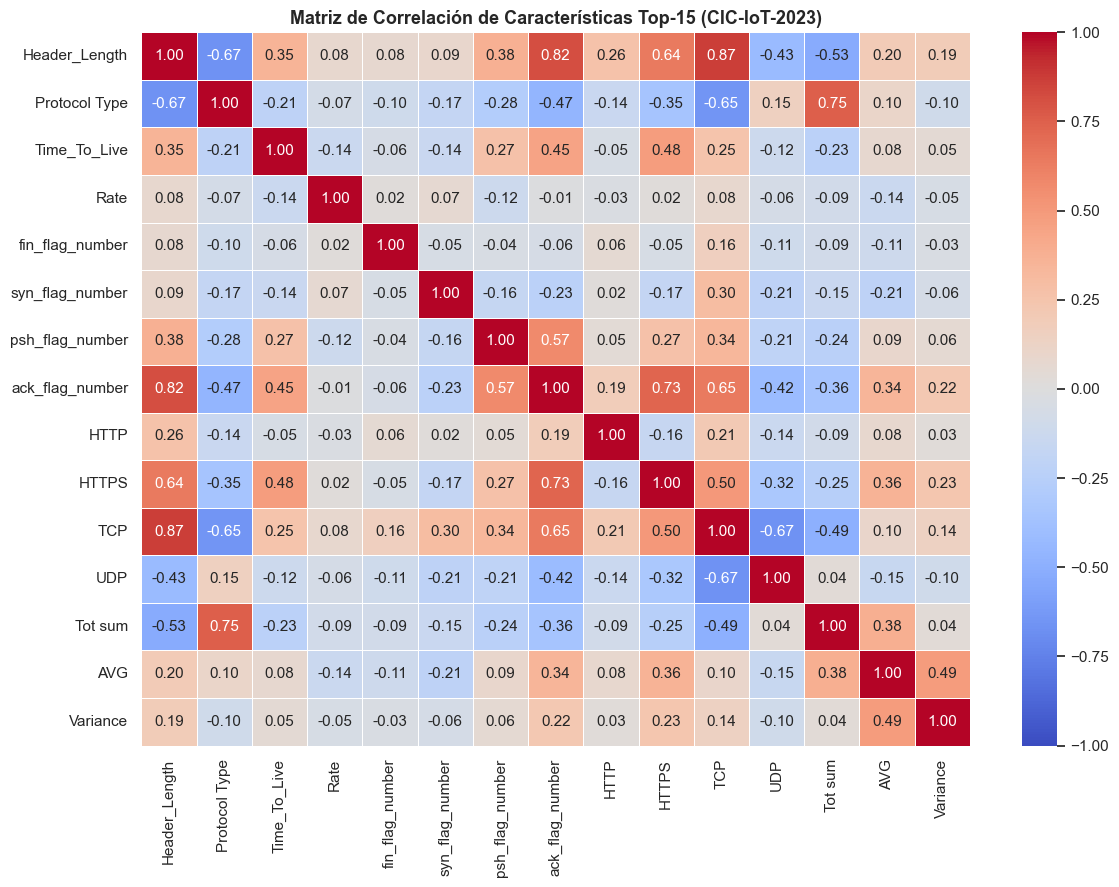

In [6]:
top_15_features = ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number',
                    'psh_flag_number', 'ack_flag_number', 'HTTP', 'HTTPS', 'TCP', 'UDP', 'Tot sum', 'AVG', 'Variance']

corr_matrix = train_df[top_15_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Características Top-15 (CIC-IoT-2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

--- 
## 6. Resumen de la Partición Estratificada (Train / Val / Test)
Verificamos la división estratificada generada para los experimentos de Deep Learning.

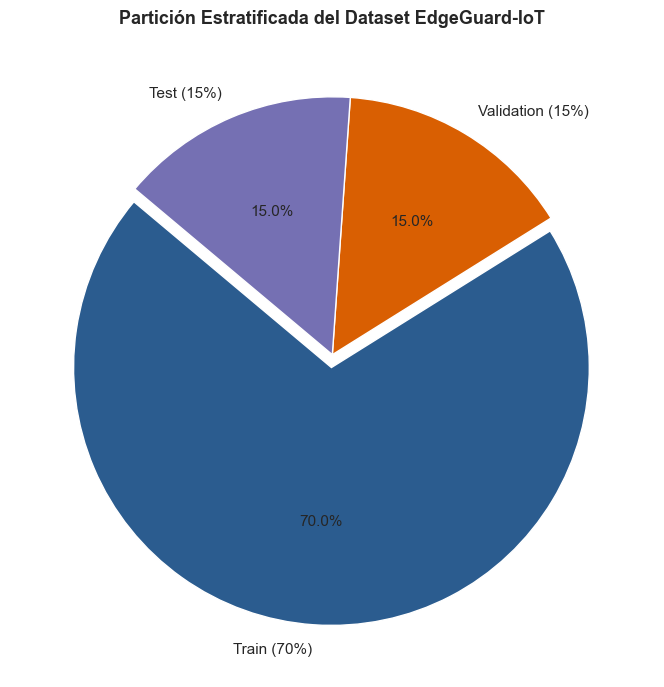

Train shape:      (130424, 40)
Validation shape: (27948, 40)
Test shape:       (27949, 40)
[+] Artefactos generados: scaler.joblib, label_encoder.joblib, meta_info.json


In [7]:
split_sizes = {'Train (70%)': len(train_df), 'Validation (15%)': len(val_df), 'Test (15%)': len(test_df)}

plt.figure(figsize=(7, 7))
plt.pie(split_sizes.values(), labels=split_sizes.keys(), autopct='%1.1f%%', colors=['#2b5c8f', '#d95f02', '#7570b3'], startangle=140, explode=(0.05, 0, 0))
plt.title('Partición Estratificada del Dataset EdgeGuard-IoT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Train shape:      {train_df.shape}')
print(f'Validation shape: {val_df.shape}')
print(f'Test shape:       {test_df.shape}')
print(f'[+] Artefactos generados: scaler.joblib, label_encoder.joblib, meta_info.json')